<a href="https://colab.research.google.com/github/amrita13/LanchesterModelOnKurskData/blob/main/2D3DSurface.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

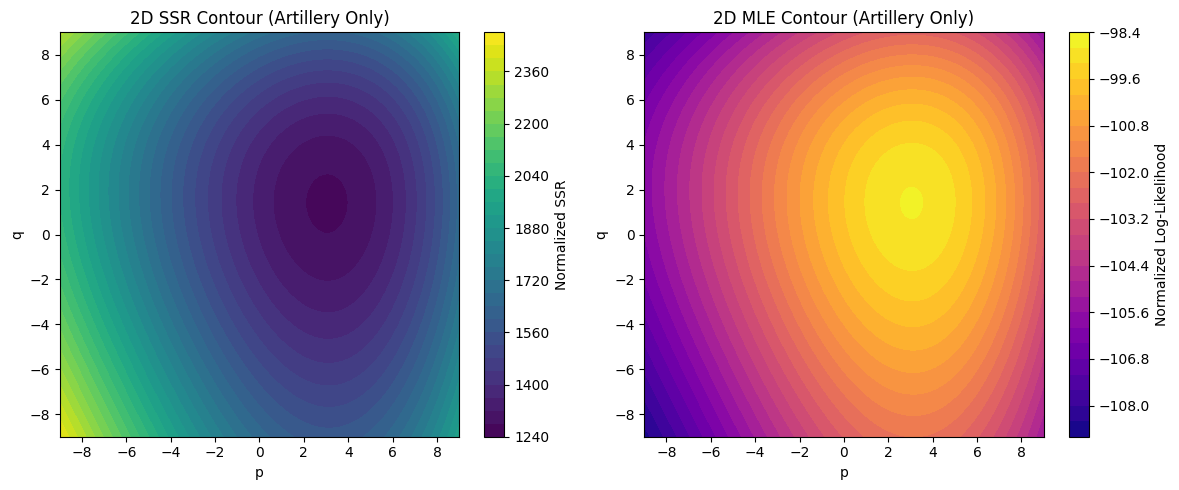

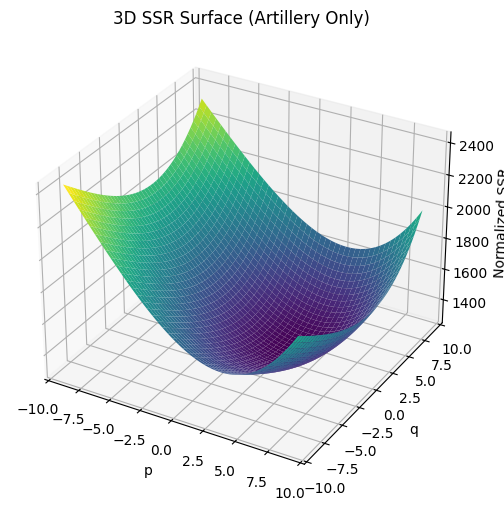

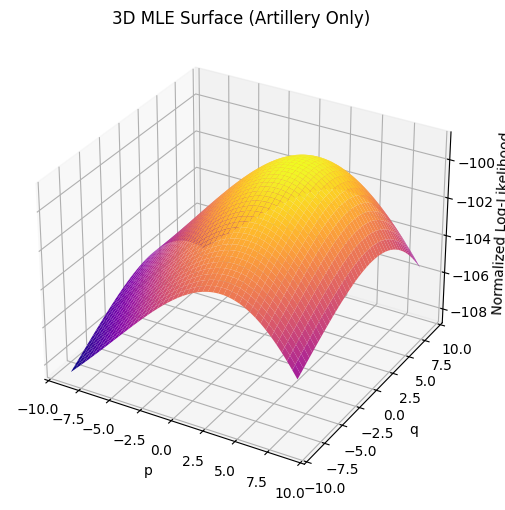

In [2]:
# Homogeneous Lanchester Model (Artillery Only) - SSR & MLE Surfaces
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Dataset (German & Soviet artillery strengths and losses)
# -------------------------------
x = np.array([
    [718, 0,    1189, 1],
    [705, 13,   1166, 24],
    [676, 30,   1161, 5],
    [661, 15,   1154, 7],
    [648, 14,   1213, 13],
    [640, 9,    1210, 6],
    [629, 13,   1199, 12],
    [628, 7,    1206, 15],
    [613, 16,   1194, 12],
    [606, 10,   1187, 7],
    [603, 5,    1184, 5],
    [601, 5,    1183, 3],
    [600, 3,    1179, 4],
    [602, 0,    1182, 2],
    [591, 4,    1182, 11]
])

B  = x[:,0]   # German artillery strength
dB = x[:,1]   # German artillery losses
R  = x[:,2]   # Soviet artillery strength
dR = x[:,3]   # Soviet artillery losses

# -------------------------------
# Step 2: Grid of exponents p, q
# -------------------------------
a, b = -9, -9
P, Q = np.meshgrid(np.arange(a, 9.1, 0.1), np.arange(b, 9.1, 0.1))
ka, kb = P.shape

SSR_surface = np.zeros((ka, kb))
LL_surface  = np.zeros((ka, kb))

# -------------------------------
# Step 3: SSR & MLE estimation loop
# -------------------------------
for k1 in range(ka):
    for l1 in range(kb):
        p = a + 0.1*(k1)
        q = b + 0.1*(l1)

        # Estimate coefficients
        a_est = np.sum(dB) / np.sum((R**p) * (B**q))
        b_est = np.sum(dR) / np.sum((B**p) * (R**q))

        # SSR calculation
        temp2 = 0
        residuals = []
        for i in range(len(B)):
            pred_dB = a_est*(R[i]**p)*(B[i]**q)
            pred_dR = b_est*(B[i]**p)*(R[i]**q)
            resG = dB[i] - pred_dB
            resS = dR[i] - pred_dR
            temp2 += resG**2 + resS**2
            residuals.append(resG); residuals.append(resS)
        SSR_surface[k1,l1] = temp2

        # MLE calculation (Gaussian likelihood)
        residuals = np.array(residuals)
        sigma2 = np.var(residuals)
        ll = -0.5*len(residuals)*np.log(2*np.pi*sigma2) - np.sum(residuals**2)/(2*sigma2)
        LL_surface[k1,l1] = ll

# # Normalize for visualization
# SSR_surface = SSR_surface / np.max(SSR_surface)
# LL_surface  = LL_surface / np.max(LL_surface)

# -------------------------------
# Step 4: Plot surfaces
# -------------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.contourf(P,Q,SSR_surface,levels=30,cmap='viridis')
plt.colorbar(label='Normalized SSR')
plt.xlabel('p'); plt.ylabel('q'); plt.title('2D SSR Contour (Artillery Only)')

plt.subplot(1,2,2)
plt.contourf(P,Q,LL_surface,levels=30,cmap='plasma')
plt.colorbar(label='Normalized Log-Likelihood')
plt.xlabel('p'); plt.ylabel('q'); plt.title('2D MLE Contour (Artillery Only)')
plt.tight_layout(); plt.show()

fig=plt.figure(figsize=(10,6)); ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(P,Q,SSR_surface,cmap='viridis')
ax.set_xlabel('p'); ax.set_ylabel('q'); ax.set_zlabel('Normalized SSR')
plt.title('3D SSR Surface (Artillery Only)')
plt.show()

fig=plt.figure(figsize=(10,6)); ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(P,Q,LL_surface,cmap='plasma')
ax.set_xlabel('p'); ax.set_ylabel('q'); ax.set_zlabel('Normalized Log-Likelihood')
plt.title('3D MLE Surface (Artillery Only)')
plt.show()
